[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leoe21/machine_learning_fundamentals/blob/main/02_unidad/02_03_regresion_logistica.ipynb)


# 02_03 Regresion Logistica 

Objetivo: aprender, paso a paso, como funciona la **regresion logistica** para clasificacion binaria.

En este notebook veremos:
- intuicion del modelo,
- preparacion de datos,
- entrenamiento y evaluacion en train/test,
- interpretacion de metricas clave,
- efecto del umbral de decision.

## 1. Que problema resuelve la regresion logistica

La regresion logistica se usa cuando la variable objetivo tiene clases (por ejemplo, 0/1).

- No predice un valor continuo como 17.3.
- Predice una **probabilidad** de pertenecer a la clase 1.
- Luego esa probabilidad se convierte en clase con un umbral (usualmente 0.5).

## 2. Formula base e intuicion

La idea central es:

$$
P(y=1 \mid X) = \sigma(z) = \frac{1}{1 + e^{-z}}, \quad z = \beta_0 + \beta_1x_1 + \cdots + \beta_px_p
$$

- La parte lineal es `z`.
- La funcion sigmoide transforma `z` a un valor entre 0 y 1.
- Si la probabilidad es alta, el modelo tiende a predecir clase 1.

In [11]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
)

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## 3. Carga de datos reales (Breast Cancer - sklearn)

Este dataset clasifica tumores como:
- `0`: malignant
- `1`: benign

Lo usamos porque es estandar, limpio y muy util para aprender clasificacion binaria.

In [12]:
data = load_breast_cancer(as_frame=True)
df = data.frame.copy()

print("Forma del dataset:", df.shape)
print("\nPrimeras filas:")
display(df.head())

print("\nDistribucion de clases (target):")
display(df["target"].value_counts().rename(index={0: "malignant", 1: "benign"}).to_frame("conteo"))

# Diccionario de datos (didactico)
def describe_feature(name):
    # name viene como: "mean radius", "radius error", "worst perimeter", etc.
    if name.startswith("mean "):
        base = name.replace("mean ", "")
        return f"Media de {base} en la imagen del nucleo celular"
    if name.endswith(" error"):
        base = name.replace(" error", "")
        return f"Error estandar de {base}"
    if name.startswith("worst "):
        base = name.replace("worst ", "")
        return f"Peor valor observado de {base}"
    return "Caracteristica morfologica del nucleo"

dict_features = pd.DataFrame(
    {
        "variable": data.feature_names,
        "descripcion": [describe_feature(v) for v in data.feature_names],
    }
)

dict_target = pd.DataFrame(
    {
        "variable_objetivo": ["target"],
        "clase_0": ["malignant (tumor maligno)"],
        "clase_1": ["benign (tumor benigno)"],
    }
)

print("\nDiccionario de variables predictoras:")
display(dict_features)

print("Diccionario de variable objetivo:")
display(dict_target)

Forma del dataset: (569, 31)

Primeras filas:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0



Distribucion de clases (target):


,conteo
target,
benign,357
malignant,212



Diccionario de variables predictoras:


,variable,descripcion
0,mean radius,Media de radius en la imagen del nucleo celular
1,mean texture,Media de texture en la imagen del nucleo celular
2,mean perimeter,Media de perimeter en la imagen del nucleo cel...
3,mean area,Media de area en la imagen del nucleo celular
4,mean smoothness,Media de smoothness en la imagen del nucleo ce...
5,mean compactness,Media de compactness en la imagen del nucleo c...
6,mean concavity,Media de concavity en la imagen del nucleo cel...
7,mean concave points,Media de concave points en la imagen del nucle...
8,mean symmetry,Media de symmetry en la imagen del nucleo celular
9,mean fractal dimension,Media de fractal dimension en la imagen del nu...


Diccionario de variable objetivo:


,variable_objetivo,clase_0,clase_1
0,target,malignant (tumor maligno),benign (tumor benigno)


**Comentario del resultado (seccion 3):** El dataset tiene tamano suficiente para practica introductoria y una distribucion de clases razonable. El diccionario de datos ayuda a interpretar mejor cada variable antes de modelar.

## 4. Separacion train/test

Separamos datos para simular un escenario real: entrenamos con train y evaluamos en datos no vistos (test).

**Importante:** si evaluamos solo en train, podemos sobreestimar el desempeno real del modelo.

In [13]:
X = df.drop(columns=["target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("y_train clase 1 (%):", round(100 * y_train.mean(), 2))
print("y_test clase 1 (%):", round(100 * y_test.mean(), 2))

X_train: (426, 30) | X_test: (143, 30)
y_train clase 1 (%): 62.68
y_test clase 1 (%): 62.94


**Comentario del resultado (seccion 4):** Train y test mantienen casi la misma proporcion de clase positiva por usar `stratify`. Esto evita comparaciones sesgadas y mejora la validez de las metricas.

## 5. Pipeline y calibracion de hiperparametros

Usamos un pipeline para evitar fugas de informacion:
- `StandardScaler` (fit solo en train)
- `LogisticRegression`

Calibramos `C` (inverso de regularizacion) y `penalty` con validacion cruzada sobre train.

Interpretacion de `C` en regresion logistica:

- **`C` pequeno** -> mayor regularizacion -> modelo mas **conservador**.
- **`C` grande** -> menor regularizacion -> modelo mas **flexible**.

En simple:
- **Conservador**: menos sensible al ruido, frontera mas estable, pero puede subajustar.
- **Flexible**: se adapta mas al train, pero puede sobreajustar.

Aqui elegimos `C` por validacion cruzada para balancear generalizacion y ajuste.

In [14]:
pipe = Pipeline(
    steps=[
        ("scale", StandardScaler()),
        (
            "model",
            LogisticRegression(
                solver="liblinear",
                max_iter=2000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

param_grid = {
    "model__penalty": ["l1", "l2"],
    "model__C": np.logspace(-3, 2, 10),
}

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_
print("Mejores hiperparametros:", grid.best_params_)
print("Mejor ROC-AUC CV:", round(grid.best_score_, 4))

Mejores hiperparametros: {'model__C': 0.1668100537200059, 'model__penalty': 'l2'}
Mejor ROC-AUC CV: 0.9951


**Comentario del resultado (seccion 5):** El mejor modelo por validacion cruzada usa regularizacion `L2` con `C=0.1668`. Un `ROC-AUC CV` muy alto indica que la combinacion elegida separa bien las clases durante el proceso de calibracion.

## 6. Evaluacion final en test

Ahora si evaluamos en test (datos no usados para ajustar hiperparametros).

In [15]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

metrics_test = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_proba),
}

print("Metricas en TEST:")
for k, v in metrics_test.items():
    print(f"- {k}: {v:.4f}")

Metricas en TEST:
- accuracy: 0.9860
- precision: 0.9889
- recall: 0.9889
- f1: 0.9889
- roc_auc: 0.9973


**Comentario del resultado (seccion 6):** Las metricas en test son altas y consistentes (`accuracy`, `precision`, `recall`, `f1` y `roc_auc`). Esto sugiere buena generalizacion sobre datos no vistos, que es el objetivo real de evaluacion.

## 7. Matriz de confusion e interpretacion

La matriz de confusion resume aciertos y errores por clase.

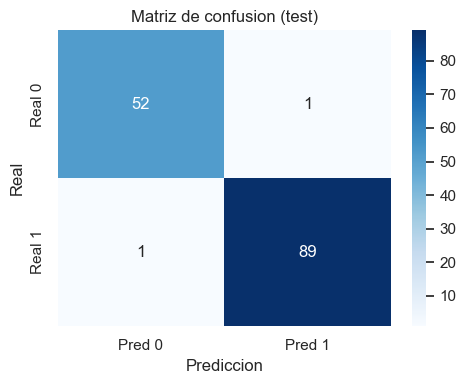

Reporte de clasificacion:

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        53
      benign       0.99      0.99      0.99        90

    accuracy                           0.99       143
   macro avg       0.99      0.99      0.99       143
weighted avg       0.99      0.99      0.99       143



In [16]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred 0", "Pred 1"],
    yticklabels=["Real 0", "Real 1"],
)
plt.title("Matriz de confusion (test)")
plt.xlabel("Prediccion")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

print("Reporte de clasificacion:\n")
print(classification_report(y_test, y_pred, target_names=["malignant", "benign"]))

**Comentario del resultado (seccion 7):** La matriz de confusion y el reporte muestran muy pocos errores absolutos. Esto confirma que el modelo funciona bien en ambas clases, no solo en la clase mayoritaria.

## 8. Curva ROC

La curva ROC muestra el trade-off entre tasa de verdaderos positivos y falsos positivos para distintos umbrales.

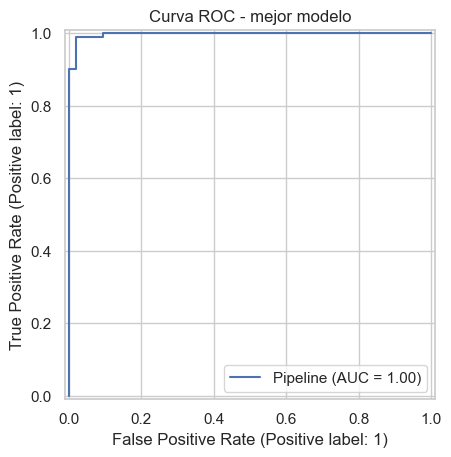

In [17]:
RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.title("Curva ROC - mejor modelo")
plt.grid(True)
plt.show()

**Comentario del resultado (seccion 8):** La curva ROC queda muy cerca de la esquina superior izquierda, lo que indica alta capacidad de separacion entre clases. Un AUC cercano a 1 sugiere que, en este dataset, el modelo discrimina muy bien casos benignos y malignos.

## 9. Umbral de decision (0.5 vs 0.3)

Por defecto se usa umbral 0.5. Si bajamos el umbral, normalmente sube el recall y puede bajar la precision.

Esto es util cuando "no detectar un positivo" cuesta mas que una falsa alarma.

In [18]:
def predict_with_threshold(proba, threshold=0.5):
    return (proba >= threshold).astype(int)

y_pred_05 = predict_with_threshold(y_proba, 0.5)
y_pred_03 = predict_with_threshold(y_proba, 0.3)

comparison = pd.DataFrame(
    {
        "threshold": [0.5, 0.3],
        "precision": [precision_score(y_test, y_pred_05), precision_score(y_test, y_pred_03)],
        "recall": [recall_score(y_test, y_pred_05), recall_score(y_test, y_pred_03)],
        "f1": [f1_score(y_test, y_pred_05), f1_score(y_test, y_pred_03)],
    }
)

display(comparison)

,threshold,precision,recall,f1
0,0.5,0.988889,0.988889,0.988889
1,0.3,0.927835,1.000000,0.962567


**Comentario del resultado (seccion 9):** Al bajar el umbral de `0.5` a `0.3`, el modelo captura mas positivos (`recall` sube a `1.00`), pero aumenta falsos positivos (`precision` baja). Esta celda muestra claramente el trade-off clasico entre sensibilidad y precision.

## 10. Conclusiones 

### 10.1 Lectura de los resultados mas importantes

- **Calidad de datos y clases:** el dataset tiene `569` registros y `30` variables predictoras (mas `target`). La distribucion de clases (`benign=357`, `malignant=212`) muestra desbalance moderado, pero no extremo.
- **Split correcto:** train y test conservan proporcion similar de clase positiva (`~62.7%` vs `~62.9%`) gracias a `stratify`, lo cual hace mas confiable la comparacion.
- **Mejor modelo por CV:** `penalty='l2'` y `C=0.1668`, con `ROC-AUC CV=0.9951`. Esto indica separacion muy alta entre clases en validacion cruzada.
- **Desempeno final en test:** `accuracy=0.9860`, `precision=0.9889`, `recall=0.9889`, `f1=0.9889`, `roc_auc=0.9973`. En conjunto, el modelo generaliza de forma excelente en este problema.
- **Matriz de confusion y reporte:** tanto para `malignant` como para `benign` se observan metricas cercanas a `0.98-0.99`, con muy pocos errores absolutos.
- **Curva ROC (grafico compartido):** la curva se pega a la esquina superior izquierda y el AUC aparece ~`1.00`, lo que confirma capacidad de discriminacion casi perfecta en test.

### 10.2 Conclusion sobre el umbral (0.5 vs 0.3)

- Con **umbral 0.5** se logra balance muy alto: precision/recall/f1 `~0.989`.
- Con **umbral 0.3** el `recall` sube a `1.000` (captura todos los positivos), pero baja la `precision` (`0.928`) y el `f1` (`0.963`).
- **Interpretacion de negocio:** si es mas costoso no detectar un caso positivo, conviene bajar umbral; si es mas costoso generar falsas alarmas, conviene mantenerlo mas alto.

### 10.3 Cierre metodologico

- El flujo esta bien planteado: **entrenamiento y calibracion solo en train**, y **evaluacion final solo en test**.
- Este rendimiento tan alto es razonable en este dataset educativo, pero en produccion siempre se recomienda validar en datos nuevos del contexto real (cambio de distribucion).

**Siguiente practica sugerida:** repetir este flujo en otro dataset binario y comparar como cambian ROC-AUC y la matriz de confusion al mover el umbral.